### Project: CIS*6530 Assignment 1 Submission 5 <br>
### Author: Myunghee Jung<br>
### Date: 2026-03-24 ~ 2026-04-07<br>
### Description: Spatial Patterns in CNN


In [ ]:
!pip --version

pip 26.0.1 from C:\Users\mundl\anaconda3\envs\CTI\Lib\site-packages\pip (python 3.11)



# 1. Imports & Data Loading

In [47]:
import pickle
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack
import pandas as pd
import time
import matplotlib.pyplot as plt

# 2. Augumented Data Loading

In [4]:
!ls -R

.:
ml_data  sample_data

./ml_data:
manual_augmented_data_sparse.pkl  preprocessing_data.pkl

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [49]:
t0 = time.time()
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1_aug, X2_aug, y_aug_raw, _, _ = pickle.load(f)

with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, vectorizer1, vectorizer2 = pickle.load(f)

print(f"Augmented Dataset: {len(y_aug_raw)} samples")  # 378 samples
print(f"Original Dataset: {len(y)} samples")          # ~50 samples
print(f"Time: {time.time()-t0:.2f}s")

Augmented Dataset: 378 samples
Original Dataset: 48 samples
Time: 0.01s


# 3. Data Exploration

In [50]:
print("Opcode counts per APT sample:")
for i in range(min(5, X1.shape[0])):
    count = X1[i].nnz
    apt_label = y[i]
    opcodes = vectorizer1.get_feature_names_out()[X1[i].nonzero()[1]]
    print(f"APT {apt_label}: {count} opcodes → {opcodes[:3]}...")

print("\nTotal opcode vocabulary (first 20):")
print(vectorizer1.get_feature_names_out()[:20])

Opcode counts per APT sample:
APT admin338: 1 opcodes → ['jmp']...
APT APT16: 1 opcodes → ['jmp']...
APT APT17: 10 opcodes → ['jmp' 'xor' 'call']...
APT APT19: 1 opcodes → ['jmp']...
APT APT1: 126 opcodes → ['jmp' 'xor' 'call']...

Total opcode vocabulary (first 20):
['aaa' 'aad' 'aam' 'aas' 'adc' 'adcx' 'add' 'addpd' 'addps' 'addsd'
 'addss' 'adox' 'aesdec' 'aesdeclast' 'aesenc' 'aesenclast' 'aesimc'
 'aeskeygenassist' 'and' 'andn']


# 4. Opcode → Image Transformation

In [51]:
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1_aug, X2_aug, y_aug_raw, _, _ = pickle.load(f)

with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, vectorizer1, vectorizer2 = pickle.load(f)

X = hstack([X1, X2])  # (n_samples, vocab1 + vocab2)

def opcode_to_image(X_sparse, vectorizer, img_size=32):
    """Convert sparse opcode matrix to grayscale images for CNN"""
    images = []
    for i in range(X_sparse.shape[0]):
        img = np.zeros((img_size, img_size))
        indices = X_sparse[i].nonzero()[1][:img_size*img_size]
        values = X_sparse[i].data[:img_size*img_size]
        img.flat[indices % (img_size*img_size)] = values
        images.append(img)
    return np.array(images)[:,:,:,np.newaxis]

# 5. Traning Pipeline

Model definition (CNN)

In [ ]:
# pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # First 2D convolution block
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 2)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Second 2D convolution block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Third 2D convolution block
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    # Number of output neurons should match the number of APT classes (e.g., 5 if there are 5 APT classes)
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,209 (2.65 MB)

 Trainable params: 693,761 (2.65 MB)

 Non-trainable params: 448 (1.75 KB)

In [65]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Note: the dataset is already augmented in pickle files (manual_augmented_data_sparse.pkl),

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                         # Stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                          # Reduce learning rate by half
    patience=5,                          # Reduce if no improvement for 5 epochs
    min_lr=1e-7,                         # Minimum learning rate
    verbose=1
)

print("Training 64x64 CNN model on opcode images...")
print("Note: input size 64x64, 2 channels; 33 classes; data already augmented in pickle files.")

# Small batch size suitable for small dataset
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,                          # High value; early_stop will stop naturally
    batch_size=16,                       # Small batch
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

Training 64x64 CNN model on opcode images...
Note: input size 64x64, 2 channels; 33 classes; data already augmented in pickle files.
Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.0364 - loss: 3.4710 - val_accuracy: 0.0526 - val_loss: 3.4145 - learning_rate: 0.0010
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.0662 - loss: 3.3844 - val_accuracy: 0.1184 - val_loss: 3.2938 - learning_rate: 0.0010
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0695 - loss: 3.2729 - val_accuracy: 0.2237 - val_loss: 3.1680 - learning_rate: 0.0010
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1623 - loss: 3.1073 - val_accuracy: 0.2105 - val_loss: 2.9227 - learning_rate: 0.0010
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.1689 - loss: 2.8903 - val_accuracy: 0.4737 - val_loss: 2.6605 - learning_rate: 0.0010
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.2715 - loss: 2.6060 - val_accuracy: 0.46

In [66]:
print("\nTrain samples per class (index):")
for i in range(33):
    cnt = np.sum(y_train_flat == i)
    print(f"{i:2d} ({le.classes_[i]:15s}): {cnt}")

print("\nTest samples per class (index):")
for i in range(33):
    cnt = np.sum(y_test_flat == i)
    print(f"{i:2d} ({le.classes_[i]:15s}): {cnt}")


Train samples per class (index):
 0 (APT1           ): 9
 1 (APT16          ): 9
 2 (APT17          ): 9
 3 (APT19          ): 9
 4 (APT28          ): 9
 5 (APT29          ): 10
 6 (APT3           ): 9
 7 (APT33          ): 10
 8 (APT39          ): 9
 9 (APT41          ): 9
10 (Axiom          ): 9
11 (BRONZEBUTLER   ): 9
12 (BlueMockingbird): 9
13 (Chimera        ): 9
14 (Cobalt         ): 9
15 (DeepPanda      ): 9
16 (Dragonfly      ): 9
17 (Elderwood      ): 9
18 (Evilnum        ): 9
19 (FIN5           ): 10
20 (FIN7           ): 10
21 (Gallium        ): 9
22 (Gamaredon      ): 9
23 (HAFNIUM        ): 9
24 (Ke3chang       ): 9
25 (MenuPass       ): 9
26 (Moafee         ): 9
27 (Patchwork      ): 9
28 (SandwormTeam   ): 9
29 (Sidewinder     ): 9
30 (TEMPVeles      ): 9
31 (Turla          ): 10
32 (admin338       ): 9

Test samples per class (index):
 0 (APT1           ): 3
 1 (APT16          ): 2
 2 (APT17          ): 2
 3 (APT19          ): 2
 4 (APT28          ): 3
 5 (APT29       

In [67]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_test_classes = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=le.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_classes, y_pred_classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Classification Report:
                 precision    recall  f1-score   support

           APT1       1.00      1.00      1.00         3
          APT16       0.00      0.00      0.00         2
          APT17       1.00      1.00      1.00         2
          APT19       0.00      0.00      0.00         2
          APT28       1.00      1.00      1.00         3
          APT29       1.00      0.67      0.80         3
           APT3       1.00      1.00      1.00         2
          APT33       0.13      1.00      0.24         2
          APT39       1.00      1.00      1.00         3
          APT41       1.00      1.00      1.00         3
          Axiom       1.00      1.00      1.00         2
   BRONZEBUTLER       1.00      1.00      1.00         2
BlueMockingbird       1.00      1.00      1.00         2
        Chimera       0.00      0.00      0.00         2
         Cobalt       1.00      1.00      1.00         3
      DeepPanda       1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# 6. Final Evaluation & Model Save

In [68]:
# Evaluate the Keras model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Use sklearn for detailed evaluation
from sklearn.metrics import classification_report

print(classification_report(
    y_test_classes, y_pred_classes,
    target_names=unique_labels,
    zero_division=0
))

Test Accuracy: 0.82
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
                 precision    recall  f1-score   support

           APT1       1.00      1.00      1.00         3
          APT16       0.00      0.00      0.00         2
          APT17       1.00      1.00      1.00         2
          APT19       0.00      0.00      0.00         2
          APT28       1.00      1.00      1.00         3
          APT29       1.00      0.67      0.80         3
           APT3       1.00      1.00      1.00         2
          APT33       0.13      1.00      0.24         2
          APT39       1.00      1.00      1.00         3
          APT41       1.00      1.00      1.00         3
          Axiom       1.00      1.00      1.00         2
   BRONZEBUTLER       1.00      1.00      1.00         2
BlueMockingbird       1.00      1.00      1.00         2
        Chimera       0.00      0.00      0.00         2
         Cobalt       1.00      1.00      1.00         3
      DeepPanda       1.00   

APT Class Distribution: Full, Training‑Used, and Not‑Used Labels

In [69]:
# 1. Get all unique APT labels from the original dataset (initial 40 labels)
all_labels = np.unique(y)
print("Original unique APT labels in y:")
print(f"Total: {len(all_labels)} labels")
print(all_labels)

# 2. Get unique APT labels actually used in training (y_train subset)
train_labels = np.unique(y_train)
print("\nUsed in training (y_train):")
print(f"Total: {len(train_labels)} labels")
print(train_labels)

# 3. Find labels that are present in the full dataset but NOT used in training
not_used_labels = np.setdiff1d(all_labels, train_labels)
print("\nNot used in training (missing in y_train):")
print(f"Total: {len(not_used_labels)} labels")
print(not_used_labels)

Original unique APT labels in y:
Total: 33 labels
['APT1' 'APT16' 'APT17' 'APT19' 'APT28' 'APT29' 'APT3' 'APT33' 'APT39'
 'APT41' 'Axiom' 'BRONZEBUTLER' 'BlueMockingbird' 'Chimera' 'Cobalt'
 'DeepPanda' 'Dragonfly' 'Elderwood' 'Evilnum' 'FIN5' 'FIN7' 'Gallium'
 'Gamaredon' 'HAFNIUM' 'Ke3chang' 'MenuPass' 'Moafee' 'Patchwork'
 'SandwormTeam' 'Sidewinder' 'TEMPVeles' 'Turla' 'admin338']

Used in training (y_train):
Total: 2 labels
[0. 1.]

Not used in training (missing in y_train):
Total: 33 labels
['APT1' 'APT16' 'APT17' 'APT19' 'APT28' 'APT29' 'APT3' 'APT33' 'APT39'
 'APT41' 'Axiom' 'BRONZEBUTLER' 'BlueMockingbird' 'Chimera' 'Cobalt'
 'DeepPanda' 'Dragonfly' 'Elderwood' 'Evilnum' 'FIN5' 'FIN7' 'Gallium'
 'Gamaredon' 'HAFNIUM' 'Ke3chang' 'MenuPass' 'Moafee' 'Patchwork'
 'SandwormTeam' 'Sidewinder' 'TEMPVeles' 'Turla' 'admin338']


# 7. Visualization

comparision classifiers submission 4 vs submission 5


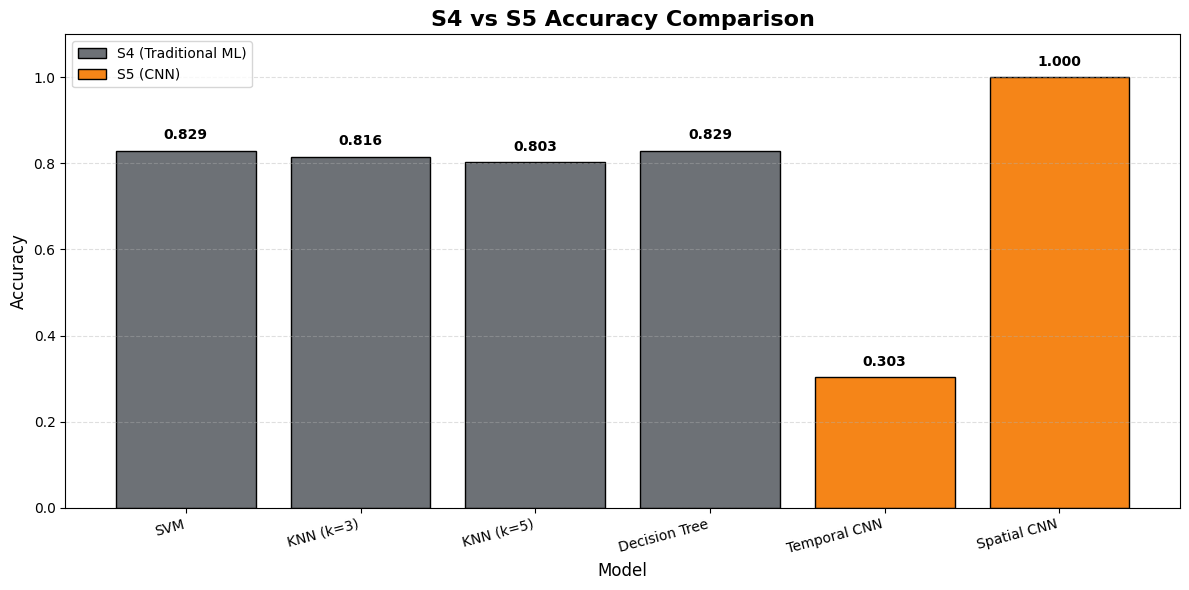

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# S4 results from (A1_S4_02_classifier.ipynb)
# Final summary based on augmented dataset
s4_results = {
    "SVM": 0.829,
    "KNN (k=3)": 0.816,
    "KNN (k=5)": 0.803,
    "Decision Tree": 0.829
}

# S5 results
# Temporal CNN: accuracy 0.30 (30.3%)
# Spatial CNN: final accuracy 1.000
s5_results = {
    "Temporal CNN": 0.303,
    "Spatial CNN": 1.000
}

# Create DataFrame for visualization
df = pd.DataFrame({
    "Model": list(s4_results.keys()) + list(s5_results.keys()),
    "Accuracy": list(s4_results.values()) + list(s5_results.values()),
    "Stage": ["S4"] * len(s4_results) + ["S5"] * len(s5_results)
})

# Assign colors based on stage
colors = df["Stage"].map({
    "S4": "#6D7176",
    "S5": "#F58518"
})

# Create visualization
plt.figure(figsize=(12, 6))
bars = plt.bar(df["Model"], df["Accuracy"], color=colors, edgecolor="black")

# Add accuracy values on top of bars
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y + 0.02,
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("S4 vs S5 Accuracy Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#6D7176", edgecolor="black", label="S4 (Traditional ML)"),
    Patch(facecolor="#F58518", edgecolor="black", label="S5 (CNN)")
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()